# Chess Play-Style Clustering
Unsupervised exploration of player archetypes using board features + clock features.

**Pipeline**
1. Feature engineering (same loader as `chess_elo_v_final`)
2. Per-player profile aggregation
3. Dimensionality reduction — t-SNE and UMAP
4. Clustering — K-Means and HDBSCAN
5. Archetype labelling & visualisation

> Toggle every behaviour from the **CONFIGURATION** cell — nowhere else.


In [123]:
# pip install chess zstandard lightgbm umap-learn hdbscan pandas scikit-learn matplotlib seaborn joblib
import io, re, time, os, warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import zstandard as zstd

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
from joblib import Parallel, delayed

import umap
import hdbscan

from chess_features_final import extract_features_dataframe

warnings.filterwarnings('ignore')
print('All imports OK')


All imports OK


## ⚙️ CONFIGURATION — edit here only

In [124]:
# ===============================================================================
#  CONFIGURATION — edit here only
# ===============================================================================

# ── output folder ──────────────────────────────────────────────────────────────
# Set this to the directory where ALL outputs (plots, CSV, report) will be saved.
# Accepts absolute paths or paths relative to this notebook.
OUTPUT_FOLDER = "./data_output"   # <-- CHANGE ME

DATA_PATH    = "../../data/villads_data/lichess_db_standard_rated_2017-11.pgn.zst"
MAX_GAMES    = 1_000_000      # reduce for faster iteration
RANDOM_STATE = 42
N_JOBS       = -1

# ── filters ────────────────────────────────────────────────────────────────────
FILTER_BASE_SECONDS  = 600   # None = all time controls
MIN_TOTAL_PLIES      = 12
EXCLUDE_TERMINATIONS = {"Abandoned", "Unterminated"}

# ── feature groups ─────────────────────────────────────────────────────────────
FEATURE_GROUPS = {
    'structure':  True,
    'checks':     True,
    'captures':   True,
    'castling':   True,
    'style':      True,
    'clock':      True,
    'engine':     False,   # needs [%eval] tags in PGN
}

# ── per-player aggregation ─────────────────────────────────────────────────────
# Recommended True when you have player IDs (e.g., 'White'/'Black' usernames).
AGGREGATE_BY_PLAYER  = True
MIN_GAMES_PER_PLAYER = 5

# ── clustering options ─────────────────────────────────────────────────────────
INCLUDE_ELO_IN_CLUSTERING = False
APPLY_LOG1P_ZERO_INFLATED = True  # promotions/en-passant counts

# ── diagnostics ────────────────────────────────────────────────────────────────
RUN_DIAGNOSTICS     = False
DIAG_SAMPLE         = 20_000
RUN_STABILITY_CHECK = True
STABILITY_SAMPLE    = 20_000
STABILITY_SEEDS     = [RANDOM_STATE, RANDOM_STATE + 1, RANDOM_STATE + 2]

# ── dimensionality reduction ───────────────────────────────────────────────────
TSNE_PERPLEXITY   = 40
TSNE_N_ITER       = 1000
TSNE_SAMPLE       = 30_000

UMAP_N_NEIGHBORS  = 30
UMAP_MIN_DIST     = 0.00
UMAP_METRIC       = 'euclidean'

# ── clustering ─────────────────────────────────────────────────────────────────
KMEANS_K          = 7
RUN_ELBOW         = True
ELBOW_K_RANGE     = range(2, 14)

HDBSCAN_MIN_CLUSTER_SIZE  = 500
HDBSCAN_MIN_SAMPLES       = 250
HDBSCAN_CLUSTER_SELECTION = 'eom'

# ── archetype labels ───────────────────────────────────────────────────────────
KMEANS_LABELS = {
    # 0: "Aggressive Attacker",
    # 1: "Blunder King",
    # 2: "Fast & Loose",
    # 3: "Positional Player",
    # 4: "Slow & Steady",
    # 5: "Endgame Specialist",
    # 6: "Solid Defender",
}

# ── output ─────────────────────────────────────────────────────────────────────
VERBOSE_PLOTS  = True
SAVE_CSV       = False

# ── derived run tag — embedded in ALL output filenames ─────────────────────────
# Examples:  tc_600s_500000games   |   tc_none_100000games
_tc_tag  = f'tc_{FILTER_BASE_SECONDS}s' if FILTER_BASE_SECONDS is not None else 'tc_none'
_run_notes_ = "APPLY_LOG1P_ZERO_INFLATED = True"
_notes_clean = re.sub(r'[^A-Za-z0-9_-]+', '', _run_notes_.strip())
_notes_tag = f'_{_notes_clean}' if _notes_clean else ''
_run_tag = f'{_tc_tag}_{MAX_GAMES}games{_notes_tag}'

OUTPUT_FOLDER = Path(OUTPUT_FOLDER)
OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

OUTPUT_CSV    = OUTPUT_FOLDER / f'chess_clusters_{_run_tag}.csv'
OUTPUT_REPORT = OUTPUT_FOLDER / f'cluster_report_{_run_tag}.txt'

print(f'Run tag   : {_run_tag}')
print(f'Output dir: {OUTPUT_FOLDER.resolve()}')

Run tag   : tc_600s_1000000games_APPLY_LOG1P_ZERO_INFLATEDTrue
Output dir: C:\Users\villa\Desktop\AppML26\AppML_FinalProject\root\workspace\villads_sandbox\data_output


## 1 · Load data

In [125]:
games_list = []
dctx = zstd.ZstdDecompressor()

t0 = time.time()
with open(DATA_PATH, 'rb') as compressed_file:
    with dctx.stream_reader(compressed_file) as reader:
        text_stream = io.TextIOWrapper(reader, encoding='utf-8')
        current_game = {}
        for line in text_stream:
            line = line.strip()
            if line.startswith('['):
                tag = line.split(' ')[0][1:]
                val = line.split('"')[1]
                if tag in ('White', 'Black', 'WhiteElo', 'BlackElo',
                           'TimeControl', 'ECO', 'Termination', 'Result'):
                    current_game[tag] = val
            elif line.startswith('1.'):
                current_game['Moves'] = line
                if 'WhiteElo' in current_game and 'BlackElo' in current_game:
                    games_list.append(current_game)
                current_game = {}
                if len(games_list) >= MAX_GAMES:
                    break

df_raw = pd.DataFrame(games_list)
df_raw['WhiteElo'] = pd.to_numeric(df_raw['WhiteElo'], errors='coerce')
df_raw['BlackElo'] = pd.to_numeric(df_raw['BlackElo'], errors='coerce')
df_raw = df_raw.dropna(subset=['WhiteElo', 'BlackElo']).copy()
df_raw['WhiteElo'] = df_raw['WhiteElo'].astype(int)
df_raw['BlackElo'] = df_raw['BlackElo'].astype(int)
df_raw['Moves']    = df_raw['Moves'].fillna('').astype(str)

print(f'Loaded {len(df_raw):,} games in {time.time()-t0:.1f}s')

# ── optional time-control filter ──────────────────────────────────────────────
if FILTER_BASE_SECONDS is not None:
    _tc_base = (
        df_raw['TimeControl'].astype(str)
        .str.extract(r'^(\d+)\+')[0]
        .astype(float)
    )
    df_raw = df_raw[_tc_base == FILTER_BASE_SECONDS].copy().reset_index(drop=True)
    print(f'After TC filter ({FILTER_BASE_SECONDS}s): {len(df_raw):,} games')

if EXCLUDE_TERMINATIONS and 'Termination' in df_raw.columns:
    before = len(df_raw)
    df_raw = df_raw[~df_raw['Termination'].isin(EXCLUDE_TERMINATIONS)].copy().reset_index(drop=True)
    print(f'After termination filter: {len(df_raw):,} games (dropped {before-len(df_raw):,})')

# ── numeric time-control features ─────────────────────────────────────────────
if 'TimeControl' in df_raw.columns:
    _tc = df_raw['TimeControl'].astype(str).str.extract(r'^(\d+)\+(\d+)')
    df_raw['tc_base']      = pd.to_numeric(_tc[0], errors='coerce').fillna(0).astype(float)
    df_raw['tc_increment'] = pd.to_numeric(_tc[1], errors='coerce').fillna(0).astype(float)

df_raw.head(3)


Loaded 1,000,000 games in 15.6s
After TC filter (600s): 145,475 games
After termination filter: 145,132 games (dropped 343)


,White,Black,Result,WhiteElo,BlackElo,ECO,TimeControl,Termination,Moves,tc_base,tc_increment
0,emaema,hazretpolat,0-1,1391,1411,C20,600+0,Normal,1. e4 { [%clk 0:10:00] } e5 { [%clk 0:05:00] }...,600.0,0.0
1,TheGrim123321,PaddyCologne,1-0,1374,1350,B30,600+0,Normal,1. e4 { [%clk 0:10:00] } c5 { [%clk 0:05:00] }...,600.0,0.0
2,nico_fr,iridule,1-0,1292,1304,C42,600+0,Time forfeit,1. e4 { [%clk 0:10:00] } e5 { [%clk 0:10:00] }...,600.0,0.0


## 2 · Clock features

In [126]:
_CLK_RE = re.compile(r'\[%clk\s+(\d+):(\d+):(\d+)\]')

def parse_clock_features(moves_string: str, time_control: str = '?') -> dict:
    clocks = [int(h)*3600 + int(m)*60 + int(s)
              for h, m, s in _CLK_RE.findall(moves_string)]
    clk_w, clk_b = clocks[0::2], clocks[1::2]

    tc_m      = re.match(r'(\d+)\+(\d+)', str(time_control))
    base      = int(tc_m.group(1)) if tc_m else None
    increment = int(tc_m.group(2)) if tc_m else 0
    norm      = base if base else 1

    def _spent(seq, start):
        out, prev = [], start
        for c in seq:
            if prev is not None:
                s = prev - c + increment
                if s >= 0: out.append(s)
            prev = c
        return out

    sw = _spent(clk_w, base)
    sb = _spent(clk_b, base)

    def _stats(seq):
        if not seq: return 0., 0., 0.
        a = np.array(seq)
        return float(a.mean()), float(a.std()), float(a.max())

    def _trend(seq):
        if len(seq) < 2: return 0.0
        x = np.arange(len(seq))
        slope = np.polyfit(x, np.array(seq, dtype=float), 1)[0]
        return float(slope)

    def _window_mean(seq, n=10, which='first'):
        if not seq: return 0.0
        return float(np.mean(seq[:n])) if which == 'first' else float(np.mean(seq[-n:]))

    aw, sw2, mw = _stats(sw)
    ab, sb2, mb = _stats(sb)

    return {
        'avg_time_norm_white':         aw / norm,
        'std_time_norm_white':         sw2 / norm,
        'max_time_norm_white':         mw / norm,
        'time_pressure_white':         sum(1 for c in clk_w if c < 10),
        'opening_pace_norm_white':     (np.mean(sw[:10]) if sw else 0.) / norm,
        'clock_remaining_norm_white':  (clk_w[-1] / norm) if clk_w else 0.,
        'opening_time_norm_white':     _window_mean(sw, 10, 'first') / norm,
        'endgame_time_norm_white':     _window_mean(sw, 10, 'last') / norm,
        'time_spent_trend_norm_white': _trend(sw) / norm,
        'avg_time_norm_black':         ab / norm,
        'std_time_norm_black':         sb2 / norm,
        'max_time_norm_black':         mb / norm,
        'time_pressure_black':         sum(1 for c in clk_b if c < 10),
        'opening_pace_norm_black':     (np.mean(sb[:10]) if sb else 0.) / norm,
        'clock_remaining_norm_black':  (clk_b[-1] / norm) if clk_b else 0.,
        'opening_time_norm_black':     _window_mean(sb, 10, 'first') / norm,
        'endgame_time_norm_black':     _window_mean(sb, 10, 'last') / norm,
        'time_spent_trend_norm_black': _trend(sb) / norm,
    }

if FEATURE_GROUPS['clock']:
    tc_col = df_raw['TimeControl'] if 'TimeControl' in df_raw.columns else ['?']*len(df_raw)
    clock_records = Parallel(n_jobs=N_JOBS)(
        delayed(parse_clock_features)(m, t)
        for m, t in zip(df_raw['Moves'], tc_col)
    )
    df_clocks = pd.DataFrame(clock_records, index=df_raw.index)
    print('Clock features:', df_clocks.shape)
else:
    df_clocks = pd.DataFrame(index=df_raw.index)
    print('Clock features skipped')


Clock features: (145132, 18)


## 3 · Board features

In [127]:
t0       = time.time()
df_feats = extract_features_dataframe(df_raw, n_jobs=N_JOBS)
elapsed  = time.time() - t0
print(f'Extracted {len(df_feats):,} games in {elapsed:.1f}s  ({elapsed/len(df_feats)*1000:.1f} ms/game)')


Extracted 145,132 games in 57.0s  (0.4 ms/game)


## 4 · Build clustering feature matrix

In [128]:
# ── feature lists ─────────────────────────────────────────────────────────────
_BOARD_FEATURES = {
    'structure': ['total_ply_count', 'material_balance_end', 'result_encoded'],
    'checks':    ['checks_given_white', 'checks_given_black',
                  'check_density_white', 'check_density_black'],
    'captures':  ['first_capture_move_white', 'first_capture_move_black',
                  'pawn_captures_total', 'piece_captures_total', 'capture_density'],
    'castling':  ['castle_move_white', 'castle_move_black'],
    'style':     ['consec_same_piece_white', 'consec_same_piece_black',
                  'queen_moves_before_10', 'white_territory_depth', 'black_territory_depth',
                  'promotions', 'en_passant_captures',
                  'legal_moves_white_move5', 'legal_moves_black_move5'],
    'engine':    ['acpl_white', 'inaccuracy_count_white', 'mistake_count_white',
                  'blunder_count_white', 'blunder_density_white',
                  'acpl_black', 'inaccuracy_count_black', 'mistake_count_black',
                  'blunder_count_black', 'blunder_density_black'],
}
_CLOCK_FEATURES = [
    'avg_time_norm_white', 'std_time_norm_white', 'max_time_norm_white',
    'time_pressure_white', 'opening_pace_norm_white', 'clock_remaining_norm_white',
    'opening_time_norm_white', 'endgame_time_norm_white', 'time_spent_trend_norm_white',
    'avg_time_norm_black', 'std_time_norm_black', 'max_time_norm_black',
    'time_pressure_black', 'opening_pace_norm_black', 'clock_remaining_norm_black',
    'opening_time_norm_black', 'endgame_time_norm_black', 'time_spent_trend_norm_black',
]

CLUSTER_FEATURES = []
for grp, cols in _BOARD_FEATURES.items():
    if FEATURE_GROUPS.get(grp, False):
        CLUSTER_FEATURES += cols
if FEATURE_GROUPS['clock']:
    CLUSTER_FEATURES += _CLOCK_FEATURES

# ── derived play-style composites ─────────────────────────────────────────────
# These are extra engineered features specifically useful for clustering
# player archetypes — they summarise cross-side patterns.

meta_cols = ['WhiteElo', 'BlackElo']
if 'tc_base' in df_raw.columns:
    meta_cols += ['tc_base', 'tc_increment']

df = (
    df_raw[meta_cols]
    .join(df_feats, how='inner')
    .join(df_clocks, how='inner')
)
df = df.replace([np.inf, -np.inf], np.nan)

# Symmetric (colour-blind) composites
# avg_elo is computed for plotting/reporting but not used in clustering by default.
df['avg_elo']             = (df['WhiteElo'] + df['BlackElo']) / 2
df['check_density_avg']   = df[['check_density_white','check_density_black']].mean(axis=1)
df['capture_agression']   = df['piece_captures_total'] / (df['total_ply_count'].clip(1))
df['pawn_aggression']     = df['pawn_captures_total']  / (df['total_ply_count'].clip(1))
df['consec_piece_avg']    = df[['consec_same_piece_white','consec_same_piece_black']].mean(axis=1)
df['time_pressure_avg']   = df[['time_pressure_white','time_pressure_black']].mean(axis=1)
df['avg_time_avg']        = df[['avg_time_norm_white','avg_time_norm_black']].mean(axis=1)
df['clock_remaining_avg'] = df[['clock_remaining_norm_white','clock_remaining_norm_black']].mean(axis=1)
df['opening_pace_avg']    = df[['opening_pace_norm_white','opening_pace_norm_black']].mean(axis=1)
df['time_variability']    = df[['std_time_norm_white','std_time_norm_black']].mean(axis=1)

COMPOSITE_FEATURES = [
    'check_density_avg', 'capture_agression', 'pawn_aggression',
    'consec_piece_avg', 'queen_moves_before_10',
    'time_pressure_avg', 'avg_time_avg', 'clock_remaining_avg',
    'opening_pace_avg', 'time_variability',
    'total_ply_count', 'castle_move_white', 'castle_move_black',
    'white_territory_depth', 'black_territory_depth',
    'promotions', 'en_passant_captures',
    'material_balance_end',
]
if INCLUDE_ELO_IN_CLUSTERING:
    COMPOSITE_FEATURES = ['avg_elo'] + COMPOSITE_FEATURES
if FEATURE_GROUPS['engine']:
    COMPOSITE_FEATURES += [
        'blunder_density_white', 'blunder_density_black',
        'acpl_white', 'acpl_black',
    ]

COMPOSITE_FEATURES = [c for c in COMPOSITE_FEATURES if c in df.columns]
print(f'Composite clustering features: {len(COMPOSITE_FEATURES)}')

# ── impute + scale ─────────────────────────────────────────────────────────────
X_raw = df[COMPOSITE_FEATURES].copy()
if APPLY_LOG1P_ZERO_INFLATED:
    _log_cols = [c for c in ['promotions', 'en_passant_captures'] if c in X_raw.columns]
    if _log_cols:
        X_raw[_log_cols] = np.log1p(X_raw[_log_cols])

imputer = SimpleImputer(strategy='median')
X_imp   = imputer.fit_transform(X_raw)
scaler  = RobustScaler()
X_scaled = scaler.fit_transform(X_imp)

print(f'Clustering matrix: {X_scaled.shape}')

Composite clustering features: 18
Clustering matrix: (145132, 18)


## 4b · Diagnostics (correlation + PCA)

In [129]:
if RUN_DIAGNOSTICS:
    rng = np.random.default_rng(RANDOM_STATE)
    _diag_n = min(DIAG_SAMPLE, len(X_raw))
    _diag_idx = rng.choice(len(X_raw), size=_diag_n, replace=False)

    # Correlation heatmap (subsampled)
    _diag_df = X_raw.iloc[_diag_idx].copy()
    corr = _diag_df.corr()
    fig, ax = plt.subplots(figsize=(0.6 * len(COMPOSITE_FEATURES) + 6, 0.6 * len(COMPOSITE_FEATURES) + 4))
    sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.2, ax=ax)
    ax.set_title(f'Feature correlation heatmap  --  {_run_tag}', fontsize=10)
    plt.tight_layout()
    _corr_path = OUTPUT_FOLDER / f'corr_heatmap_{_run_tag}.png'
    plt.savefig(_corr_path, dpi=150, bbox_inches='tight')
    print(f'Saved -> {_corr_path}')
    plt.show()

    # PCA explained variance
    from sklearn.decomposition import PCA
    _n = min(20, X_imp.shape[1])
    _pca = PCA(n_components=_n)
    _pca.fit(StandardScaler().fit_transform(X_imp[_diag_idx]))
    exp = _pca.explained_variance_ratio_.cumsum()

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(range(1, _n + 1), exp, marker='o', color='#4e91d9')
    ax.set_xlabel('Number of components')
    ax.set_ylabel('Cumulative explained variance')
    ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.3)
    ax.set_title(f'PCA explained variance  --  {_run_tag}', fontsize=10)
    plt.tight_layout()
    _pca_path = OUTPUT_FOLDER / f'pca_explained_{_run_tag}.png'
    plt.savefig(_pca_path, dpi=150, bbox_inches='tight')
    print(f'Saved -> {_pca_path}')
    plt.show()

## 5 · K-Means — elbow + fit

  k=2  inertia=1,534,606  silhouette=0.2954
  k=3  inertia=1,321,704  silhouette=0.1693
  k=4  inertia=1,200,972  silhouette=0.1419
  k=5  inertia=1,127,748  silhouette=0.1151
  k=6  inertia=1,058,149  silhouette=0.1250
  k=7  inertia=1,019,021  silhouette=0.1196
  k=8  inertia=985,189  silhouette=0.0981
  k=9  inertia=950,295  silhouette=0.1121
  k=10  inertia=924,568  silhouette=0.1094
  k=11  inertia=895,937  silhouette=0.1029
  k=12  inertia=874,466  silhouette=0.1042
  k=13  inertia=852,919  silhouette=0.1053
Saved -> data_output\elbow_silhouette_tc_600s_1000000games_APPLY_LOG1P_ZERO_INFLATEDTrue.png


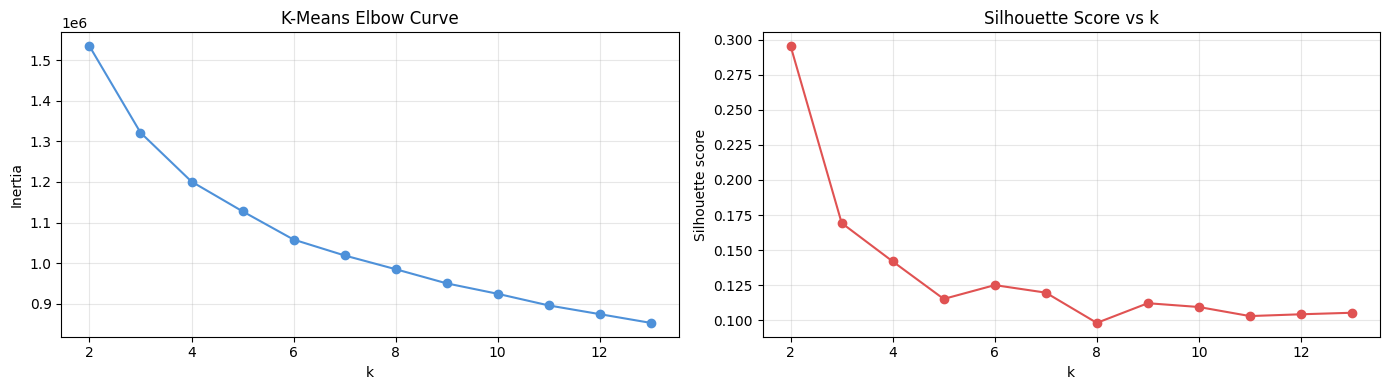

Best silhouette at k=2
K-Means (k=7) cluster sizes:
kmeans_cluster
0     7641
1    11867
2    24518
3    44368
4    20889
5     3042
6    32807
Name: count, dtype: int64


In [130]:
if RUN_ELBOW:
    inertias, sil_scores = [], []
    for k in ELBOW_K_RANGE:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init='auto')
        labels = km.fit_predict(X_scaled)
        inertias.append(km.inertia_)
        _idx = np.random.default_rng(RANDOM_STATE).choice(len(X_scaled),
               size=min(5000, len(X_scaled)), replace=False)
        sil_scores.append(silhouette_score(X_scaled[_idx], labels[_idx]))
        print(f'  k={k}  inertia={km.inertia_:,.0f}  silhouette={sil_scores[-1]:.4f}')

    if VERBOSE_PLOTS:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
        ax1.plot(list(ELBOW_K_RANGE), inertias, 'o-', color='#4e91d9')
        ax1.set_xlabel('k'); ax1.set_ylabel('Inertia')
        ax1.set_title('K-Means Elbow Curve'); ax1.grid(alpha=0.3)

        ax2.plot(list(ELBOW_K_RANGE), sil_scores, 'o-', color='#e05252')
        ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette score')
        ax2.set_title('Silhouette Score vs k'); ax2.grid(alpha=0.3)

        plt.tight_layout()
        _elbow_path = OUTPUT_FOLDER / f'elbow_silhouette_{_run_tag}.png'
        plt.savefig(_elbow_path, dpi=150, bbox_inches='tight')
        print(f'Saved -> {_elbow_path}')
        plt.show()
        print(f'Best silhouette at k={list(ELBOW_K_RANGE)[np.argmax(sil_scores)]}')

# ── final K-Means fit ──────────────────────────────────────────────────────────
km_final = KMeans(n_clusters=KMEANS_K, random_state=RANDOM_STATE, n_init=20)
df['kmeans_cluster'] = km_final.fit_predict(X_scaled)
print(f'K-Means (k={KMEANS_K}) cluster sizes:')
print(df['kmeans_cluster'].value_counts().sort_index())


## 5b · K-Means stability (lightweight)

In [131]:
if RUN_STABILITY_CHECK:
    from sklearn.metrics import adjusted_rand_score

    rng = np.random.default_rng(RANDOM_STATE)
    n = min(STABILITY_SAMPLE, len(X_scaled))
    idx = rng.choice(len(X_scaled), size=n, replace=False)

    labels_list = []
    for seed in STABILITY_SEEDS:
        km = KMeans(n_clusters=KMEANS_K, random_state=seed, n_init=20)
        labels_list.append(km.fit_predict(X_scaled[idx]))

    aris = []
    for i in range(len(labels_list)):
        for j in range(i + 1, len(labels_list)):
            aris.append(adjusted_rand_score(labels_list[i], labels_list[j]))

    ari_mean = float(np.mean(aris)) if aris else 0.0
    ari_min = float(np.min(aris)) if aris else 0.0
    summary = (
        f'K-Means stability (n={n}, k={KMEANS_K}):\n'
        f'  seeds: {STABILITY_SEEDS}\n'
        f'  ARI mean: {ari_mean:.3f}\n'
        f'  ARI min : {ari_min:.3f}\n'
    )
    print(summary)

    _stab_path = OUTPUT_FOLDER / f'kmeans_stability_{_run_tag}.txt'
    with open(_stab_path, 'w', encoding='utf-8') as fh:
        fh.write(summary)
    print(f'Saved -> {_stab_path}')

K-Means stability (n=20000, k=7):
  seeds: [42, 43, 44]
  ARI mean: 0.994
  ARI min : 0.991

Saved -> data_output\kmeans_stability_tc_600s_1000000games_APPLY_LOG1P_ZERO_INFLATEDTrue.txt


## 6 · HDBSCAN

In [132]:
# HDBSCAN needs a lower-dimensional space — we use UMAP first (faster + better structure)
# so run UMAP before HDBSCAN.
print('Running UMAP for HDBSCAN pre-reduction...')
t0 = time.time()
reducer_hdb = umap.UMAP(
    n_neighbors=UMAP_N_NEIGHBORS,
    min_dist=0.0,          # 0 = tighter clusters, better for HDBSCAN
    n_components=10,       # 10-D embedding fed to HDBSCAN
    metric=UMAP_METRIC,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
    low_memory=False,
)
X_umap_hdb = reducer_hdb.fit_transform(X_scaled)
print(f'UMAP (10-D) done in {time.time()-t0:.1f}s')

print('Running HDBSCAN...')
t0 = time.time()
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE,
    min_samples=HDBSCAN_MIN_SAMPLES,
    cluster_selection_method=HDBSCAN_CLUSTER_SELECTION,
    metric='euclidean',
    core_dist_n_jobs=N_JOBS,
    prediction_data=True,
)
df['hdbscan_cluster'] = clusterer.fit_predict(X_umap_hdb)
n_found   = df['hdbscan_cluster'].nunique() - (1 if -1 in df['hdbscan_cluster'].values else 0)
n_noise   = (df['hdbscan_cluster'] == -1).sum()
print(f'HDBSCAN done in {time.time()-t0:.1f}s  |  clusters: {n_found}  noise: {n_noise:,}')
print(df['hdbscan_cluster'].value_counts().sort_index())


Running UMAP for HDBSCAN pre-reduction...
UMAP (10-D) done in 143.4s
Running HDBSCAN...
HDBSCAN done in 49.3s  |  clusters: 7  noise: 330
hdbscan_cluster
-1      330
 0     1300
 1     6316
 2     1038
 3    29276
 4     8249
 5    38403
 6    60220
Name: count, dtype: int64


## 7 · t-SNE embedding

In [133]:
print('Running t-SNE...')
t0 = time.time()

# Subsample if configured
if TSNE_SAMPLE and TSNE_SAMPLE < len(X_scaled):
    rng     = np.random.default_rng(RANDOM_STATE)
    ts_idx  = rng.choice(len(X_scaled), size=TSNE_SAMPLE, replace=False)
    X_tsne_input = X_scaled[ts_idx]
    df_tsne = df.iloc[ts_idx].copy().reset_index(drop=True)
    _subset = True
else:
    X_tsne_input = X_scaled
    df_tsne = df.copy().reset_index(drop=True)
    ts_idx  = np.arange(len(X_scaled))
    _subset = False

# Use PCA initialisation for reproducibility & speed
tsne = TSNE(
    n_components=2,
    perplexity=TSNE_PERPLEXITY,
    random_state=RANDOM_STATE,
    init='pca',
    learning_rate='auto',
    n_jobs=N_JOBS,
)
emb_tsne = tsne.fit_transform(X_tsne_input)
print(f't-SNE done in {time.time()-t0:.1f}s')


Running t-SNE...
t-SNE done in 143.5s


## 8 · UMAP embedding (2-D visualisation)

In [134]:
print('Running UMAP (2-D)...')
t0 = time.time()

reducer_2d = umap.UMAP(
    n_neighbors=UMAP_N_NEIGHBORS,
    min_dist=UMAP_MIN_DIST,
    n_components=2,
    metric=UMAP_METRIC,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
    low_memory=False,
)
emb_umap = reducer_2d.fit_transform(X_scaled)
print(f'UMAP (2-D) done in {time.time()-t0:.1f}s')

df['umap_x'] = emb_umap[:, 0]
df['umap_y'] = emb_umap[:, 1]


Running UMAP (2-D)...
UMAP (2-D) done in 96.5s


## 9 · Visualise — t-SNE vs UMAP, coloured by cluster & Elo

Saved -> data_output\tsne_tc_600s_1000000games_APPLY_LOG1P_ZERO_INFLATEDTrue.png


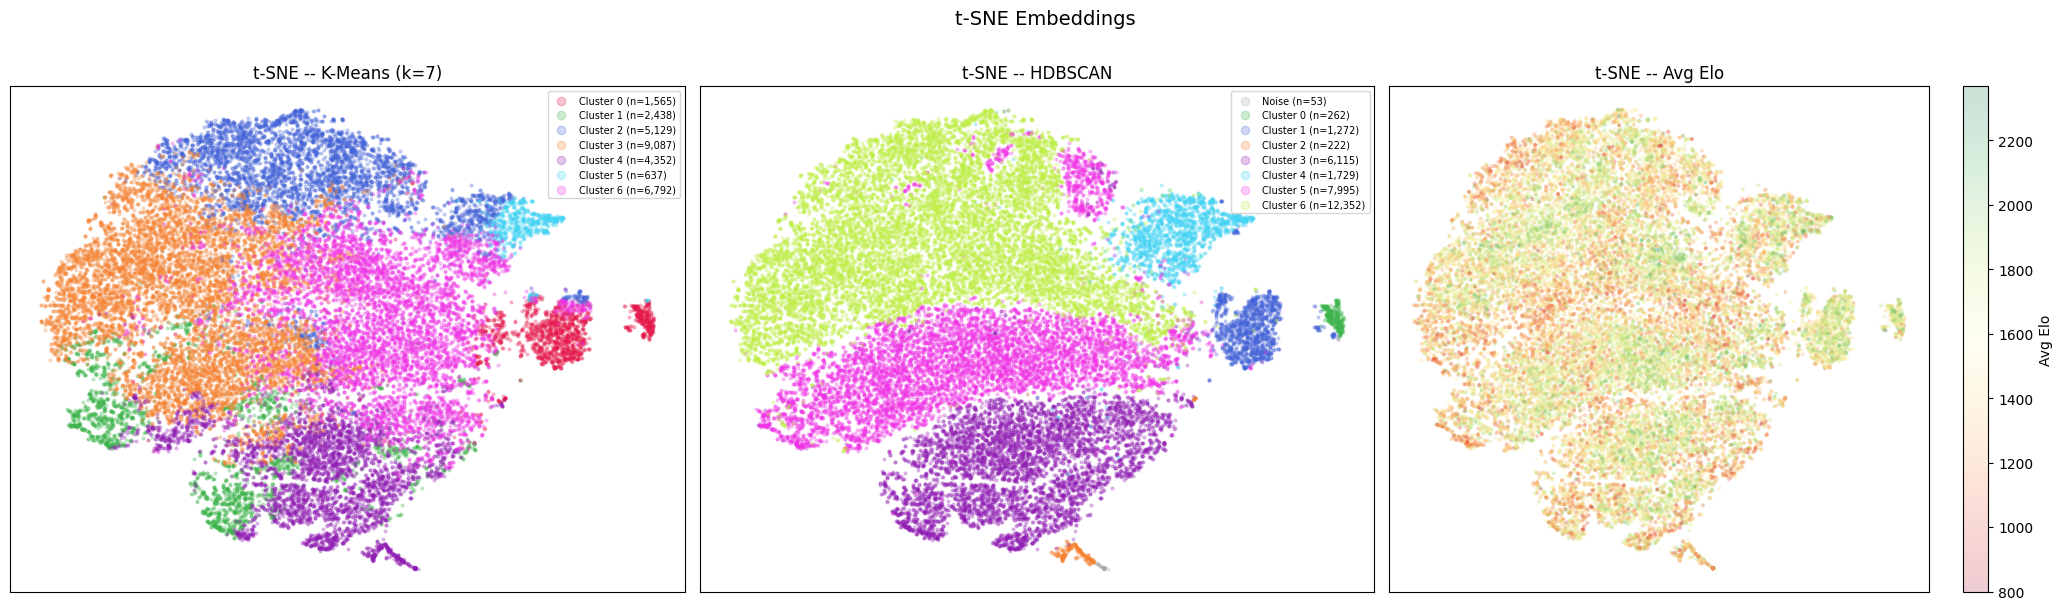

Saved -> data_output\umap_tc_600s_1000000games_APPLY_LOG1P_ZERO_INFLATEDTrue.png


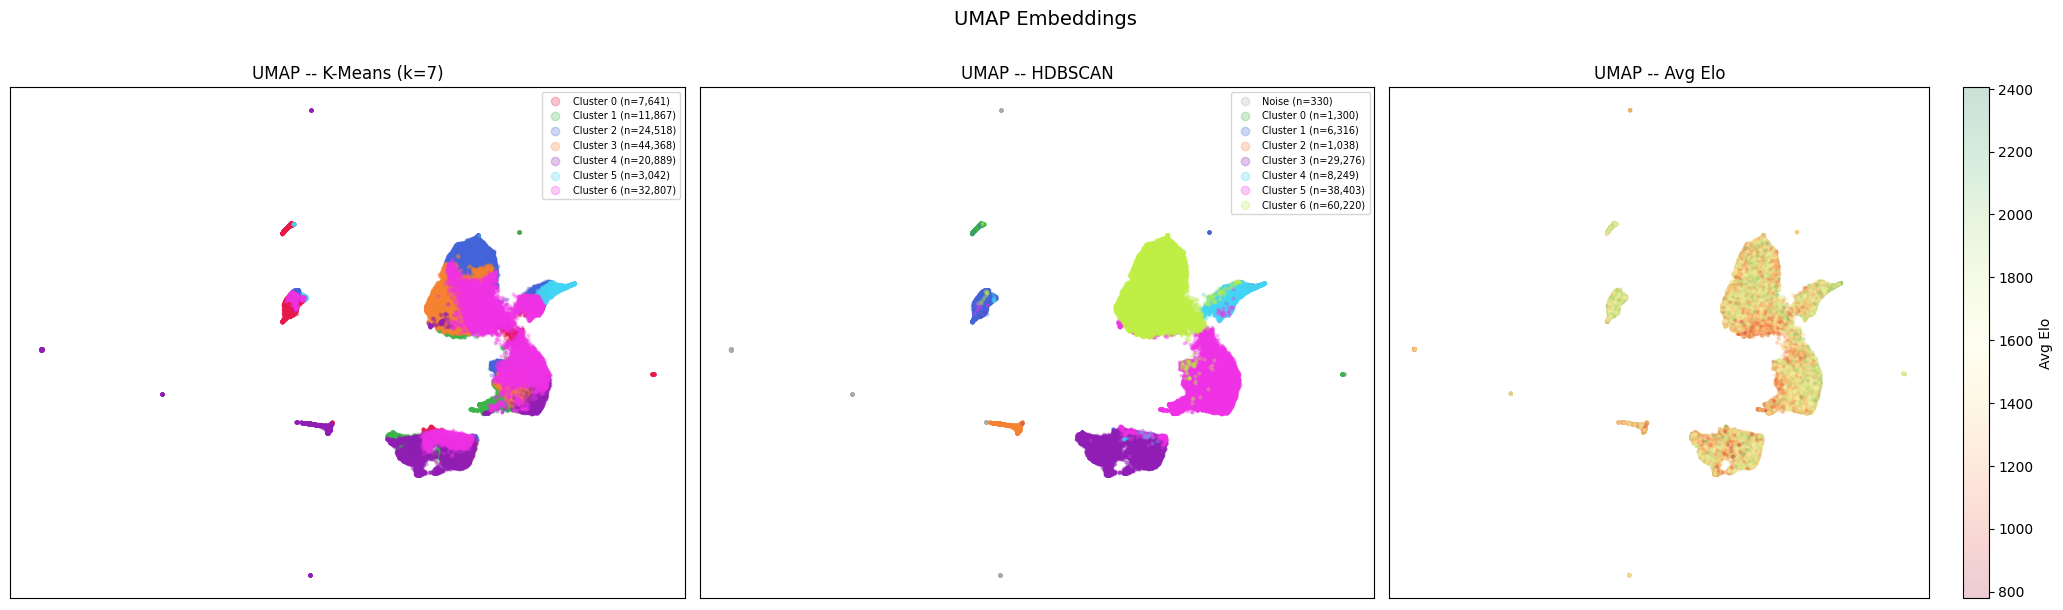

In [135]:
def _label(cluster_id: int, label_map: dict) -> str:
    return label_map.get(cluster_id, f'Cluster {cluster_id}')

PALETTE = [
    '#e6194b','#3cb44b','#4363d8','#f58231','#911eb4',
    '#42d4f4','#f032e6','#bfef45','#fabed4','#469990',
    '#dcbeff','#9a6324','#fffac8','#800000','#aaffc3',
]

def scatter_clusters(ax, x, y, labels, label_map, title, alpha=0.25, s=4):
    unique = sorted(set(labels))
    for i, c in enumerate(unique):
        mask  = labels == c
        color = '#aaaaaa' if c == -1 else PALETTE[i % len(PALETTE)]
        name  = 'Noise' if c == -1 else _label(c, label_map)
        ax.scatter(x[mask], y[mask], c=color, s=s, alpha=alpha,
                   rasterized=True, label=f'{name} (n={mask.sum():,})')
    ax.legend(loc='upper right', fontsize=7, markerscale=3)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])

if VERBOSE_PLOTS:
    # t-SNE
    fig, axes = plt.subplots(1, 3, figsize=(21, 6))
    scatter_clusters(axes[0], emb_tsne[:,0], emb_tsne[:,1],
                     df_tsne['kmeans_cluster'].values, KMEANS_LABELS,
                     f't-SNE -- K-Means (k={KMEANS_K})')
    scatter_clusters(axes[1], emb_tsne[:,0], emb_tsne[:,1],
                     df_tsne['hdbscan_cluster'].values, {}, 't-SNE -- HDBSCAN')
    sc = axes[2].scatter(emb_tsne[:,0], emb_tsne[:,1],
                         c=df_tsne['avg_elo'].values,
                         cmap='RdYlGn', s=4, alpha=0.2, rasterized=True)
    plt.colorbar(sc, ax=axes[2], label='Avg Elo')
    axes[2].set_title('t-SNE -- Avg Elo'); axes[2].set_xticks([]); axes[2].set_yticks([])
    plt.suptitle('t-SNE Embeddings', fontsize=14, y=1.01)
    plt.tight_layout()
    _tsne_path = OUTPUT_FOLDER / f'tsne_{_run_tag}.png'
    plt.savefig(_tsne_path, dpi=150, bbox_inches='tight')
    print(f'Saved -> {_tsne_path}')
    plt.show()

    # UMAP
    fig, axes = plt.subplots(1, 3, figsize=(21, 6))
    scatter_clusters(axes[0], df['umap_x'].values, df['umap_y'].values,
                     df['kmeans_cluster'].values, KMEANS_LABELS,
                     f'UMAP -- K-Means (k={KMEANS_K})')
    scatter_clusters(axes[1], df['umap_x'].values, df['umap_y'].values,
                     df['hdbscan_cluster'].values, {}, 'UMAP -- HDBSCAN')
    sc = axes[2].scatter(df['umap_x'].values, df['umap_y'].values,
                         c=df['avg_elo'].values,
                         cmap='RdYlGn', s=4, alpha=0.2, rasterized=True)
    plt.colorbar(sc, ax=axes[2], label='Avg Elo')
    axes[2].set_title('UMAP -- Avg Elo'); axes[2].set_xticks([]); axes[2].set_yticks([])
    plt.suptitle('UMAP Embeddings', fontsize=14, y=1.01)
    plt.tight_layout()
    _umap_path = OUTPUT_FOLDER / f'umap_{_run_tag}.png'
    plt.savefig(_umap_path, dpi=150, bbox_inches='tight')
    print(f'Saved -> {_umap_path}')
    plt.show()


## 10 · Cluster profiling — centroids & radar charts

=== K-Means cluster centroids ===


,avg_elo,check_density_avg,capture_agression,time_pressure_avg,avg_time_avg,clock_remaining_avg,opening_pace_avg,time_variability,queen_moves_before_10,consec_piece_avg,total_ply_count,promotions,en_passant_captures
kmeans_cluster,,,,,,,,,,,,,
0,1626.500,0.072,0.131,0.204,0.027,0.372,0.038,0.060,1.213,5.384,57.073,0.101,0.032
1,1439.592,0.080,0.089,0.000,0.013,0.827,0.011,0.012,1.927,2.223,28.200,0.004,0.019
2,1543.149,0.112,0.110,0.205,0.013,0.304,0.010,0.015,1.455,18.458,116.906,0.745,0.040
3,1533.353,0.082,0.156,0.001,0.013,0.626,0.009,0.013,1.354,5.611,59.842,0.080,0.026
4,1534.290,0.040,0.114,0.002,0.013,0.746,0.010,0.013,1.127,2.616,38.027,0.010,0.016
5,1615.754,0.102,0.105,5.218,0.015,0.085,0.016,0.023,1.290,20.160,125.419,0.680,0.040
6,1526.590,0.079,0.133,0.193,0.022,0.342,0.015,0.025,1.354,5.950,64.588,0.074,0.029



=== HDBSCAN cluster centroids ===


,avg_elo,check_density_avg,capture_agression,time_pressure_avg,avg_time_avg,clock_remaining_avg,opening_pace_avg,time_variability,queen_moves_before_10,consec_piece_avg,total_ply_count,promotions,en_passant_captures
hdbscan_cluster,,,,,,,,,,,,,
0,1662.422,0.075,0.129,0.471,0.029,0.213,0.057,0.090,1.135,7.673,69.222,0.205,0.036
1,1657.894,0.078,0.130,0.365,0.022,0.393,0.033,0.053,1.177,7.759,69.044,0.221,0.034
2,1404.091,0.012,0.000,0.000,0.011,0.941,0.011,0.010,0.581,0.322,10.204,0.000,0.000
3,1522.016,0.052,0.122,0.010,0.015,0.684,0.011,0.016,1.314,3.189,41.959,0.016,0.022
4,1579.100,0.097,0.112,2.895,0.018,0.109,0.013,0.021,1.270,15.094,108.323,0.420,0.038
5,1532.060,0.077,0.129,0.018,0.016,0.560,0.011,0.017,1.413,5.636,57.970,0.067,0.026
6,1518.440,0.095,0.138,0.018,0.015,0.473,0.011,0.016,1.446,9.740,78.064,0.318,0.030


Saved -> data_output\cluster_heatmap_tc_600s_1000000games_APPLY_LOG1P_ZERO_INFLATEDTrue.png


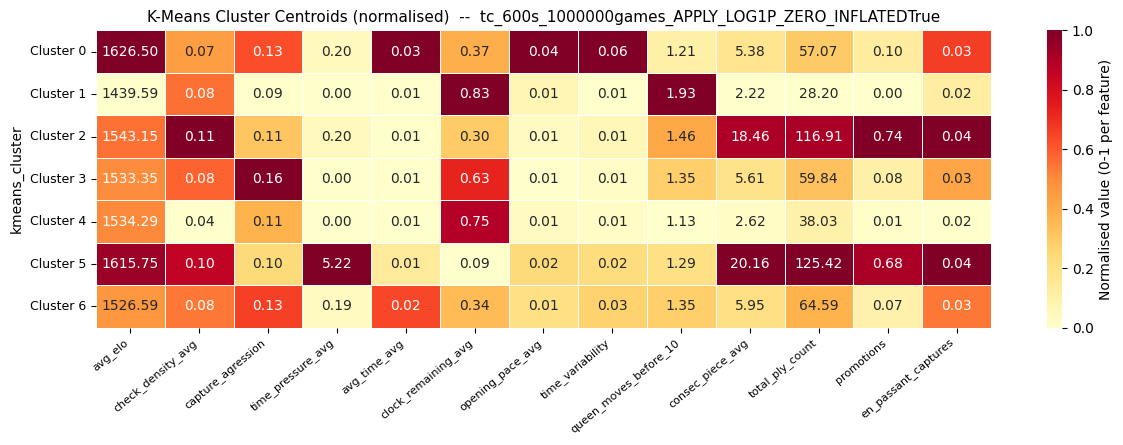

In [136]:
# ── centroid table ─────────────────────────────────────────────────────────────
_profile_cols = [
    'avg_elo', 'check_density_avg', 'capture_agression',
    'time_pressure_avg', 'avg_time_avg', 'clock_remaining_avg',
    'opening_pace_avg', 'time_variability',
    'queen_moves_before_10', 'consec_piece_avg',
    'total_ply_count', 'promotions', 'en_passant_captures',
]
_profile_cols = [c for c in _profile_cols if c in df.columns]

def cluster_profile(df_in: pd.DataFrame, cluster_col: str) -> pd.DataFrame:
    grp = df_in.groupby(cluster_col)[_profile_cols]
    return grp.mean().round(3)

km_profile  = cluster_profile(df, 'kmeans_cluster')
hdb_profile = cluster_profile(df[df['hdbscan_cluster'] >= 0], 'hdbscan_cluster')

print('=== K-Means cluster centroids ===')
display(km_profile)
print('\n=== HDBSCAN cluster centroids ===')
display(hdb_profile)

if VERBOSE_PLOTS:
    # Normalised heatmap
    norm_km = (km_profile - km_profile.min()) / (km_profile.max() - km_profile.min() + 1e-9)
    fig_h   = max(4, KMEANS_K * 0.65)
    fig_w   = max(10, len(_profile_cols) * 0.95)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    sns.heatmap(
        norm_km,
        annot=km_profile,
        fmt='.2f',
        cmap='YlOrRd',
        linewidths=0.5,
        ax=ax,
        cbar_kws={'label': 'Normalised value (0-1 per feature)'},
    )
    cluster_names = [KMEANS_LABELS.get(i, f'Cluster {i}') for i in km_profile.index]
    ax.set_yticklabels(cluster_names, rotation=0, fontsize=9)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=8)
    ax.set_title(f'K-Means Cluster Centroids (normalised)  --  {_run_tag}', fontsize=11)
    plt.tight_layout()
    _heatmap_path = OUTPUT_FOLDER / f'cluster_heatmap_{_run_tag}.png'
    plt.savefig(_heatmap_path, dpi=150, bbox_inches='tight')
    print(f'Saved -> {_heatmap_path}')
    plt.show()


Saved -> data_output\radar_kmeans_tc_600s_1000000games_APPLY_LOG1P_ZERO_INFLATEDTrue.png


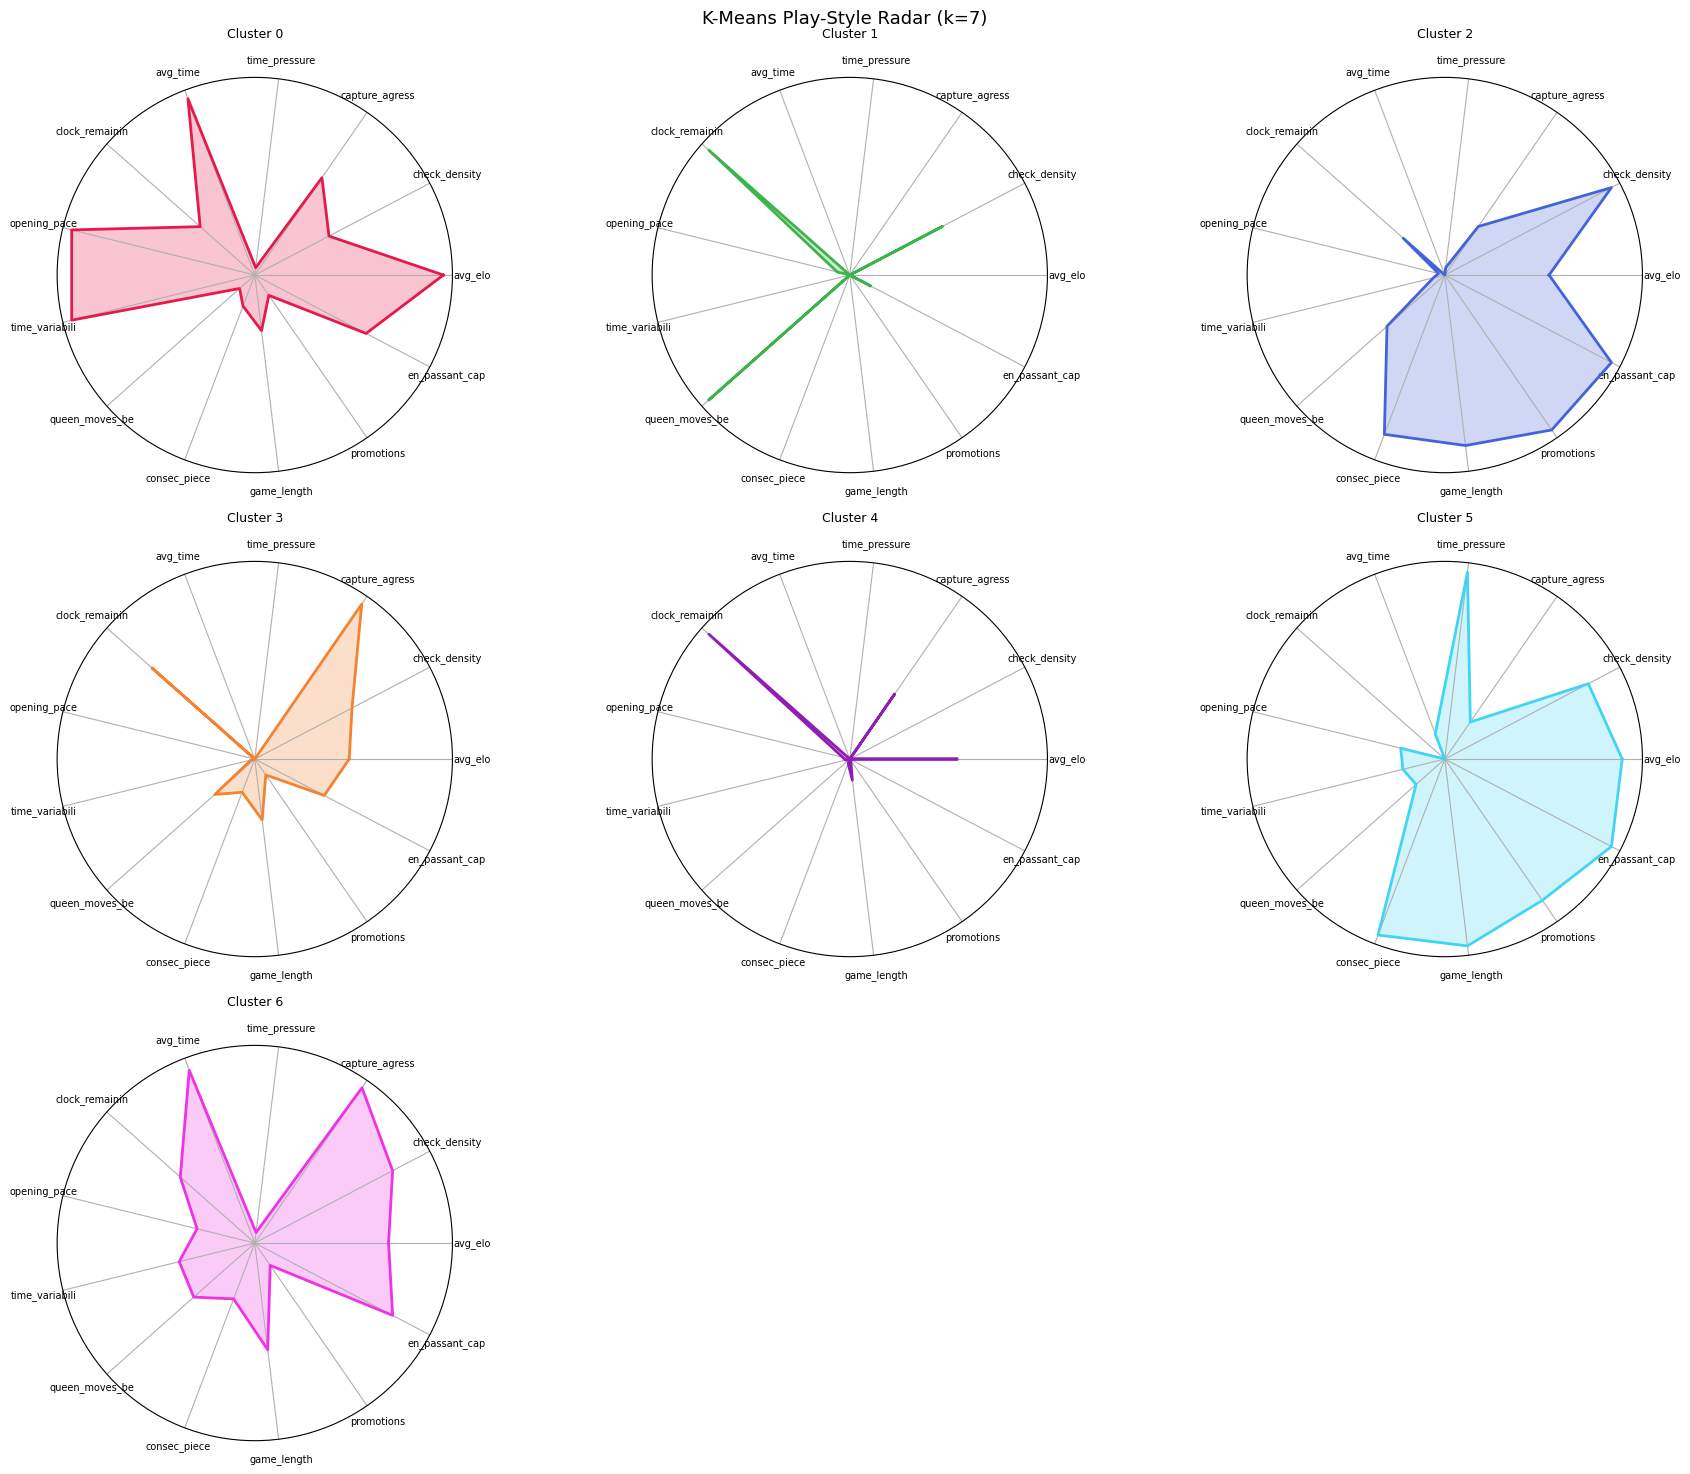

Saved -> data_output\radar_hdbscan_tc_600s_1000000games_APPLY_LOG1P_ZERO_INFLATEDTrue.png


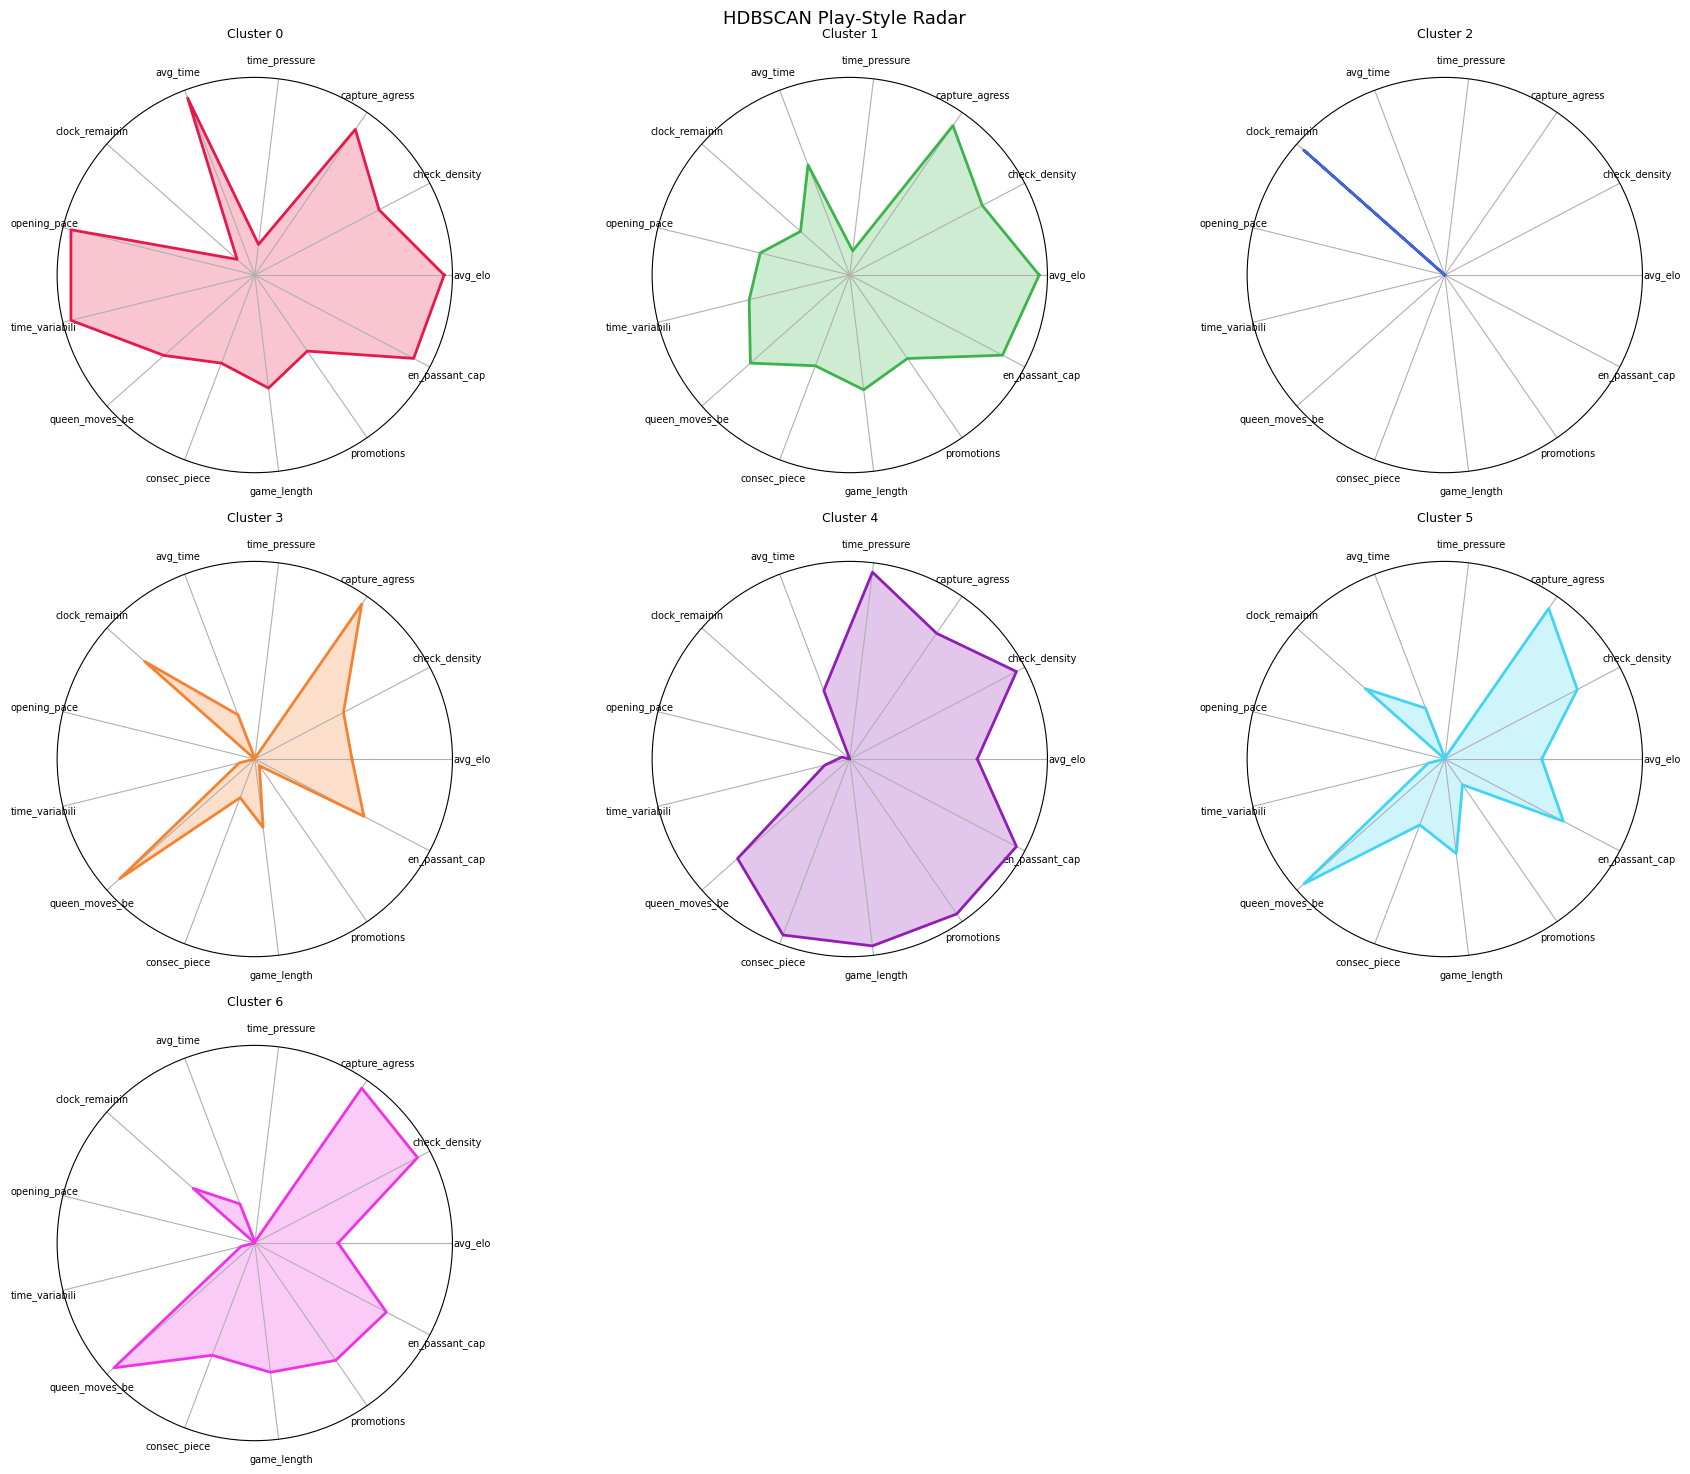

In [137]:
# ── radar chart helper ─────────────────────────────────────────────────────────
def radar_chart(profile_df: pd.DataFrame, title: str, label_map: dict = {}, save_path=None):
    norm   = (profile_df - profile_df.min()) / (profile_df.max() - profile_df.min() + 1e-9)
    cols   = list(norm.columns)
    N      = len(cols)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    nrows = (len(norm) + 2) // 3
    fig   = plt.figure(figsize=(6 * min(3, len(norm)), 5 * nrows))

    for i, (cid, row) in enumerate(norm.iterrows()):
        ax = fig.add_subplot(nrows, min(3, len(norm)), i+1, polar=True)
        vals  = row.values.tolist() + [row.values[0]]
        color = '#aaaaaa' if cid == -1 else PALETTE[i % len(PALETTE)]
        ax.plot(angles, vals, color=color, linewidth=2)
        ax.fill(angles, vals, alpha=0.25, color=color)
        ax.set_xticks(angles[:-1])
        short = [c.replace('_norm','').replace('_avg','').replace('_white','')
                   .replace('total_ply_count','game_length')[:14]
                 for c in cols]
        ax.set_xticklabels(short, fontsize=7)
        name = label_map.get(int(cid), f'Cluster {cid}') if cid != -1 else 'Noise'
        ax.set_title(name, fontsize=9, pad=12)
        ax.set_yticks([])

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved -> {save_path}')
    plt.show()

if VERBOSE_PLOTS:
    radar_chart(km_profile,  f'K-Means Play-Style Radar (k={KMEANS_K})', KMEANS_LABELS,
                save_path=OUTPUT_FOLDER / f'radar_kmeans_{_run_tag}.png')
    radar_chart(hdb_profile, 'HDBSCAN Play-Style Radar',
                save_path=OUTPUT_FOLDER / f'radar_hdbscan_{_run_tag}.png')


## 10b - Cluster statistics report - standout features per cluster

Identifies which features deviate most from the global median for each K-Means cluster and saves a full text report.

In [138]:
# ── Extended feature list ──────────────────────────────────────────────────────
_report_cols = COMPOSITE_FEATURES.copy()
_extra_side = [
    'checks_given_white', 'checks_given_black',
    'first_capture_move_white', 'first_capture_move_black',
    'castle_move_white', 'castle_move_black',
    'white_territory_depth', 'black_territory_depth',
    'pawn_captures_total', 'piece_captures_total',
]
if FEATURE_GROUPS.get('engine', False):
    _extra_side += ['acpl_white', 'acpl_black',
                    'blunder_count_white', 'blunder_count_black']
_report_cols += [c for c in _extra_side if c in df.columns and c not in _report_cols]
_report_cols  = [c for c in _report_cols if c in df.columns]

# ── Z-score of each cluster mean vs global median ──────────────────────────────
global_median   = df[_report_cols].median()
global_std      = df[_report_cols].std().replace(0, 1e-9)
km_full_profile = df.groupby('kmeans_cluster')[_report_cols].mean()
km_zscore       = (km_full_profile - global_median) / global_std

_STANDOUT_N   = 5
cluster_sizes = df['kmeans_cluster'].value_counts().sort_index()

print('=' * 72)
print(f'  CLUSTER STATISTICS REPORT  --  {_run_tag}')
print(f'  {len(df):,} games   |   K-Means k={KMEANS_K}')
print('=' * 72)

cluster_summaries = {}

for cid in sorted(df['kmeans_cluster'].unique()):
    label   = KMEANS_LABELS.get(cid, f'Cluster {cid}')
    n_games = cluster_sizes[cid]
    pct     = 100 * n_games / len(df)

    row_z     = km_zscore.loc[cid].abs().sort_values(ascending=False)
    top_feats = row_z.head(_STANDOUT_N)

    print(f'\n-- {label}  (n={n_games:,}, {pct:.1f}% of games)')
    print(f'   {"Feature":<32}  {"Cluster mean":>13}  {"Global med":>11}  {"Z-score":>8}')
    print(f'   {"-"*32}  {"-"*13}  {"-"*11}  {"-"*8}')

    feat_lines = []
    for feat in top_feats.index:
        cm = km_full_profile.loc[cid, feat]
        gm = global_median[feat]
        z  = km_zscore.loc[cid, feat]
        direction = 'UP' if z > 0 else 'DN'
        print(f'   {feat:<32}  {cm:>13.3f}  {gm:>11.3f}  {direction} {abs(z):>5.2f}')
        feat_lines.append({'feature': feat, 'cluster_mean': round(float(cm), 3),
                           'global_median': round(float(gm), 3), 'z_score': round(float(z), 2)})

    cluster_summaries[cid] = {
        'label':            label,
        'n_games':          int(n_games),
        'pct':              round(pct, 1),
        'standout_features': feat_lines,
        'profile':          km_full_profile.loc[cid].round(3).to_dict(),
    }

print('\n' + '=' * 72)


  CLUSTER STATISTICS REPORT  --  tc_600s_1000000games_APPLY_LOG1P_ZERO_INFLATEDTrue
  145,132 games   |   K-Means k=7

-- Cluster 0  (n=7,641, 5.3% of games)
   Feature                            Cluster mean   Global med   Z-score
   --------------------------------  -------------  -----------  --------
   time_variability                          0.060        0.016  UP  3.37
   opening_pace_avg                          0.038        0.010  UP  3.08
   avg_time_avg                              0.027        0.015  UP  1.71
   clock_remaining_avg                       0.372        0.525  DN  0.54
   piece_captures_total                      7.593        9.000  DN  0.37

-- Cluster 1  (n=11,867, 8.2% of games)
   Feature                            Cluster mean   Global med   Z-score
   --------------------------------  -------------  -----------  --------
   piece_captures_total                      2.734        9.000  DN  1.63
   pawn_aggression                           0.174        0.1

Saved -> data_output\cluster_standout_bars_tc_600s_1000000games_APPLY_LOG1P_ZERO_INFLATEDTrue.png


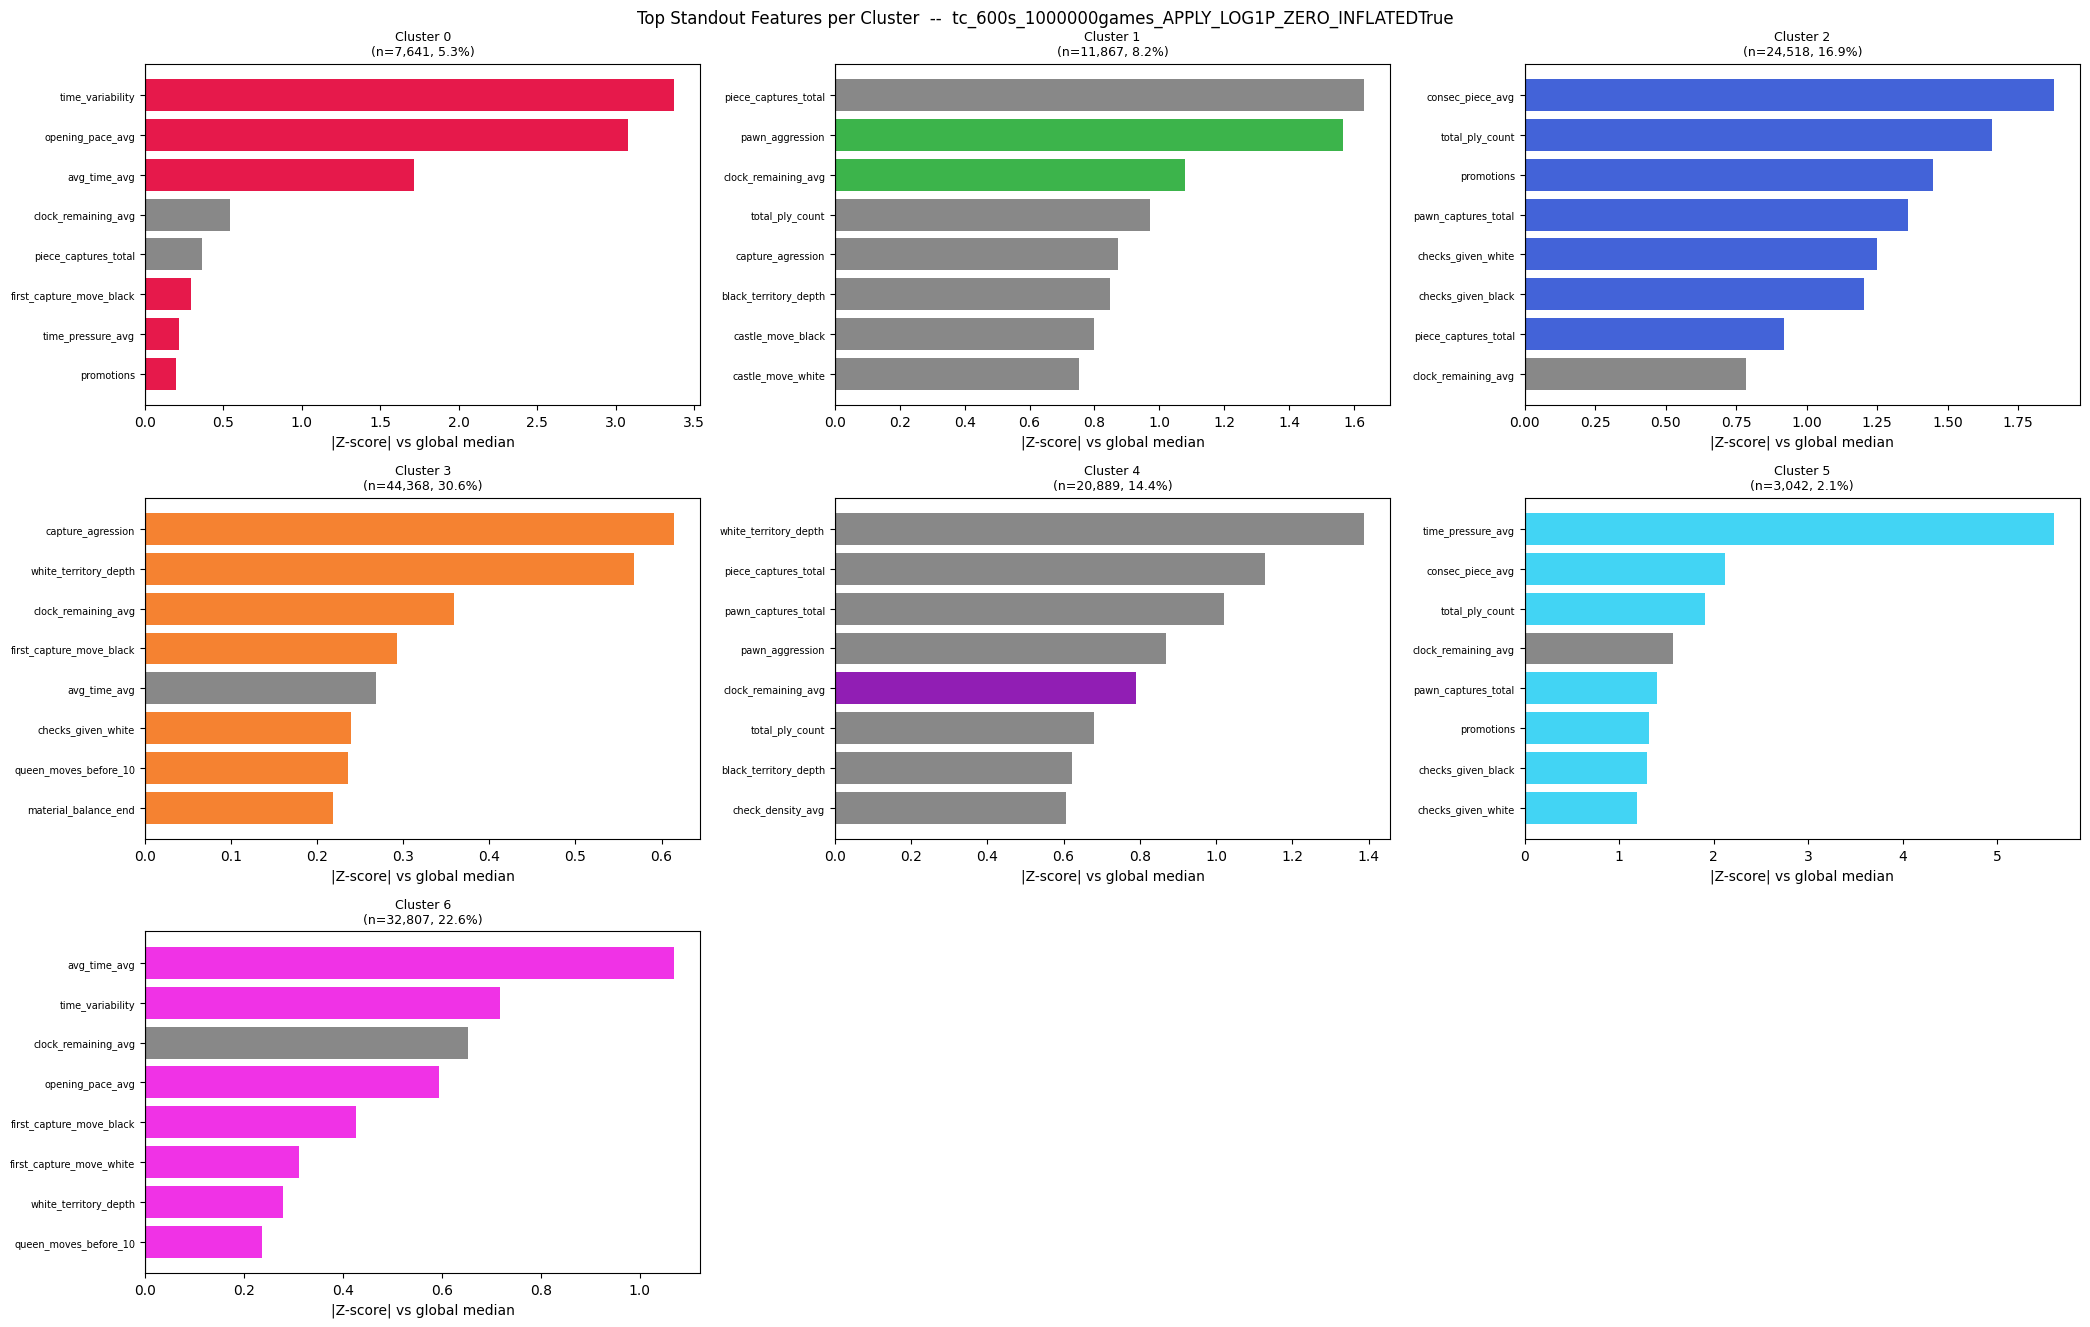

In [139]:
# ── Bar charts: standout z-scores per cluster ──────────────────────────────────
if VERBOSE_PLOTS:
    nclusters = len(km_zscore)
    ncols     = min(3, nclusters)
    nrows     = (nclusters + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 4.5 * nrows), squeeze=False)

    for idx, cid in enumerate(sorted(km_zscore.index)):
        ax    = axes[idx // ncols][idx % ncols]
        color = PALETTE[idx % len(PALETTE)]
        label = KMEANS_LABELS.get(cid, f'Cluster {cid}')

        top   = km_zscore.loc[cid].abs().sort_values(ascending=False).head(8)
        signs = km_zscore.loc[cid][top.index].values
        cols  = [color if s >= 0 else '#888888' for s in signs]

        ax.barh(top.index[::-1], top.values[::-1], color=cols[::-1])
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_xlabel('|Z-score| vs global median')
        ax.set_title(
            f"{label}\n(n={cluster_summaries[cid]['n_games']:,}, "
            f"{cluster_summaries[cid]['pct']}%)",
            fontsize=9
        )
        ax.tick_params(axis='y', labelsize=7)

    for idx in range(nclusters, nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    plt.suptitle(f'Top Standout Features per Cluster  --  {_run_tag}', fontsize=12)
    plt.tight_layout()
    _bar_path = OUTPUT_FOLDER / f'cluster_standout_bars_{_run_tag}.png'
    plt.savefig(_bar_path, dpi=150, bbox_inches='tight')
    print(f'Saved -> {_bar_path}')
    plt.show()


Saved -> data_output\cluster_violin_tc_600s_1000000games_APPLY_LOG1P_ZERO_INFLATEDTrue.png


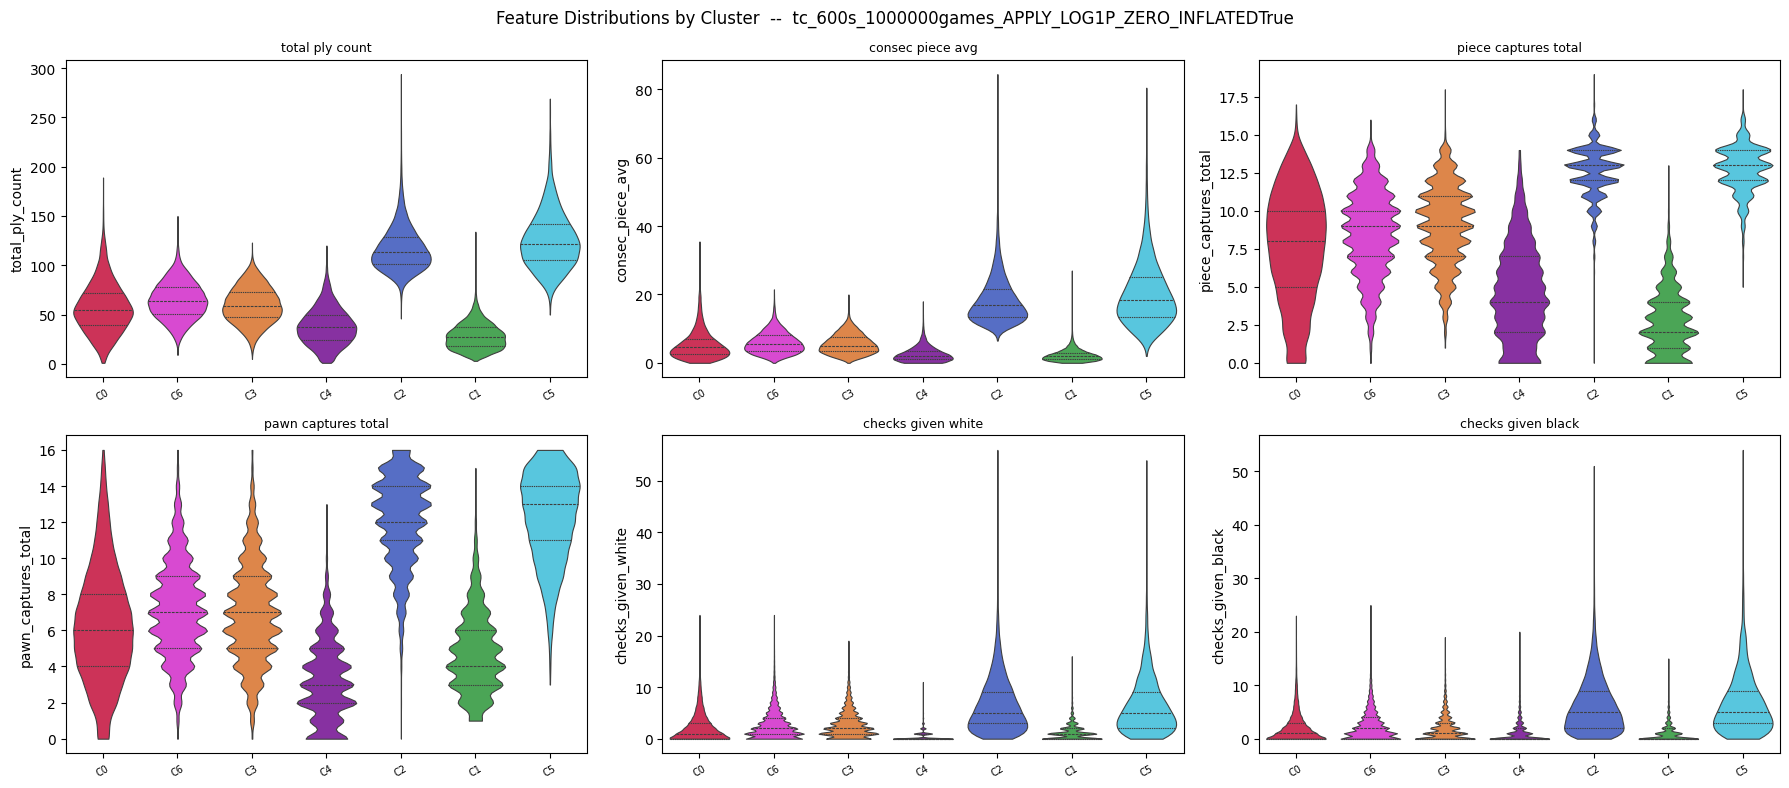

In [140]:
# ── Violin plots for the most globally-distinctive features ─────────────────────
if VERBOSE_PLOTS:
    _feat_variance = km_full_profile.std(axis=0).sort_values(ascending=False)
    _top_violin    = _feat_variance.head(6).index.tolist()

    fig, axes  = plt.subplots(2, 3, figsize=(18, 8))
    axes       = axes.flatten()
    _df_violin = df[['kmeans_cluster'] + _top_violin].copy()
    _df_violin['cluster_label'] = _df_violin['kmeans_cluster'].map(
        lambda x: KMEANS_LABELS.get(x, f'C{x}')
    )

    for i, feat in enumerate(_top_violin):
        ax = axes[i]
        palette_map = {
            KMEANS_LABELS.get(c, f'C{c}'): PALETTE[c % len(PALETTE)]
            for c in sorted(df['kmeans_cluster'].unique())
        }
        sns.violinplot(
            data=_df_violin, x='cluster_label', y=feat,
            palette=palette_map, ax=ax,
            cut=0, inner='quartile', linewidth=0.8,
        )
        ax.set_title(feat.replace('_', ' '), fontsize=9)
        ax.set_xlabel('')
        ax.tick_params(axis='x', labelsize=7, rotation=30)

    plt.suptitle(f'Feature Distributions by Cluster  --  {_run_tag}', fontsize=12)
    plt.tight_layout()
    _violin_path = OUTPUT_FOLDER / f'cluster_violin_{_run_tag}.png'
    plt.savefig(_violin_path, dpi=150, bbox_inches='tight')
    print(f'Saved -> {_violin_path}')
    plt.show()


## 11 · Archetype interpretation guide

After inspecting the centroids and radar charts, fill in `KMEANS_LABELS` in the CONFIG cell.

| Signature | Likely archetype |
|---|---|
| High `check_density_avg`, high `capture_aggression`, low `total_ply_count` | **Aggressive Attacker** |
| High `blunder_density` (engine on), high `time_pressure_avg` | **Blunder King / Time-Scrambler** |
| Low `avg_time_avg`, high `time_pressure_avg`, low `clock_remaining_avg` | **Fast & Loose** |
| Low `avg_time_avg`, low `time_pressure_avg`, high `avg_elo` | **Fast & Sharp** |
| High `avg_time_avg`, high `clock_remaining_avg`, long games | **Slow & Positional** |
| High `queen_moves_before_10`, low `castle_move_*` | **Gambit / Early Queen Rusher** |
| High `time_variability`, inconsistent `opening_pace` | **Erratic Thinker** |
| High `opening_pace_avg`, low `endgame_time_norm` | **Endgame Hoarder** |


## 12b - Save cluster text report

Writes a human-readable `.txt` summary — cluster sizes, key stats, and auto-derived player-type descriptions — to `OUTPUT_FOLDER`.

In [141]:
def _auto_describe(cid: int, summary: dict) -> str:
    """Build a short player-type paragraph from standout z-scores."""
    feats  = {f['feature']: f['z_score'] for f in summary['standout_features']}
    traits = []

    if feats.get('check_density_avg', 0) > 0.5:
        traits.append('delivers checks frequently (aggressive attacking style)')
    elif feats.get('check_density_avg', 0) < -0.5:
        traits.append('rarely delivers checks (positional / defensive tendency)')

    if feats.get('capture_agression', 0) > 0.5:
        traits.append('high piece-capture rate (tactical, piece-hungry)')
    if feats.get('pawn_aggression', 0) > 0.5:
        traits.append('heavy pawn-trading (open-position seeker)')

    if feats.get('time_pressure_avg', 0) > 0.6:
        traits.append('frequently in time pressure (risky clock management)')
    if feats.get('avg_time_avg', 0) > 0.6:
        traits.append('spends above-average time per move (deliberate thinker)')
    elif feats.get('avg_time_avg', 0) < -0.6:
        traits.append('very fast mover (instinctive / pre-moves extensively)')
    if feats.get('clock_remaining_avg', 0) > 0.6:
        traits.append('finishes games with plenty of clock remaining (efficient)')

    if feats.get('queen_moves_before_10', 0) > 0.5:
        traits.append('moves the queen early (gambit-prone or early-attack oriented)')
    if feats.get('opening_pace_avg', 0) > 0.6:
        traits.append('burns extra time in the opening (deep thinker or unfamiliar lines)')
    elif feats.get('opening_pace_avg', 0) < -0.6:
        traits.append('rapid opening moves (well-booked up)')

    if feats.get('total_ply_count', 0) > 0.6:
        traits.append('plays long games (endgame-oriented)')
    elif feats.get('total_ply_count', 0) < -0.6:
        traits.append('games end early (decisive / sharp play or blunder-prone)')

    avg_elo_val = summary['profile'].get('avg_elo', 0)
    if feats.get('avg_elo', 0) > 0.6:
        traits.append(f'above-average rating (mean Elo {avg_elo_val:.0f})')
    elif feats.get('avg_elo', 0) < -0.6:
        traits.append(f'below-average rating (mean Elo {avg_elo_val:.0f})')

    if feats.get('promotions', 0) > 0.6:
        traits.append('promotes pawns more often than average (endgame fighter)')
    if feats.get('time_variability', 0) > 0.6:
        traits.append('highly variable time usage (erratic or complex positions)')

    if not traits:
        return ('No single feature dominates; '
                'this cluster represents a balanced or average play style.')
    return 'This cluster tends to ' + '; '.join(traits) + '.'


# ── Build report lines ─────────────────────────────────────────────────────────
_TS = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
W   = 72

lines = [
    '=' * W,
    '  CHESS PLAY-STYLE CLUSTER REPORT',
    f'  Generated : {_TS}',
    f'  Run tag   : {_run_tag}',
    f'  Games     : {len(df):,}',
    f'  TC filter : {FILTER_BASE_SECONDS}s' if FILTER_BASE_SECONDS else '  TC filter : none (all time controls)',
    f'  K-Means k : {KMEANS_K}',
    '=' * W,
    '',
    'SECTION 1 -- CLUSTER OVERVIEW',
    '-' * 40,
]

for cid in sorted(cluster_summaries):
    s = cluster_summaries[cid]
    lines.append(f"  Cluster {cid:>2d}: {s['label']:<30}  n={s['n_games']:>8,}  ({s['pct']:>5.1f}%)")

lines += [
    '',
    'SECTION 2 -- STANDOUT FEATURES (Z-score vs global median)',
    '-' * 40,
]
for cid in sorted(cluster_summaries):
    s = cluster_summaries[cid]
    lines.append(f"\n  [{s['label']}]  n={s['n_games']:,} ({s['pct']}%)")
    lines.append(f"  {'Feature':<32}  {'Cluster mean':>13}  {'Global med':>11}  {'Z-score':>8}")
    lines.append(f"  {'-'*32}  {'-'*13}  {'-'*11}  {'-'*8}")
    for f in s['standout_features']:
        direction = 'UP' if f['z_score'] > 0 else 'DN'
        lines.append(
            f"  {f['feature']:<32}  {f['cluster_mean']:>13.3f}  "
            f"{f['global_median']:>11.3f}  {direction} {abs(f['z_score']):>5.2f}"
        )

lines += [
    '',
    'SECTION 3 -- PLAYER TYPE DESCRIPTIONS',
    '-' * 40,
]
for cid in sorted(cluster_summaries):
    s    = cluster_summaries[cid]
    desc = _auto_describe(cid, s)
    lines.append(f"\n  {s['label']}")
    lines.append(f"  {'=' * len(s['label'])}")
    # Word-wrap to ~68 chars
    words, cur = desc.split(), '  '
    for w in words:
        if len(cur) + len(w) + 1 > 70:
            lines.append(cur); cur = '  ' + w
        else:
            cur += (' ' if cur != '  ' else '') + w
    if cur.strip():
        lines.append(cur)

lines += [
    '',
    'SECTION 4 -- KEY FEATURE GLOBAL STATS',
    '-' * 40,
    f"  {'Feature':<32}  {'Mean':>8}  {'Median':>8}  {'Std':>8}",
    f"  {'-'*32}  {'-'*8}  {'-'*8}  {'-'*8}",
]
for c in _profile_cols:
    if c in df.columns:
        m, med, sd = df[c].mean(), df[c].median(), df[c].std()
        lines.append(f'  {c:<32}  {m:>8.3f}  {med:>8.3f}  {sd:>8.3f}')

lines += ['', '=' * W, f'  End of report  --  {_run_tag}', '=' * W]

report_text = '\n'.join(lines)
print(report_text[:3000])
if len(report_text) > 3000:
    print('... [truncated for display; full report saved to file]')

with open(OUTPUT_REPORT, 'w', encoding='utf-8') as fh:
    fh.write(report_text)
print(f'\nFull report saved -> {OUTPUT_REPORT}')


  CHESS PLAY-STYLE CLUSTER REPORT
  Generated : 2026-06-03 13:43:49
  Run tag   : tc_600s_1000000games_APPLY_LOG1P_ZERO_INFLATEDTrue
  Games     : 145,132
  TC filter : 600s
  K-Means k : 7

SECTION 1 -- CLUSTER OVERVIEW
----------------------------------------
  Cluster  0: Cluster 0                       n=   7,641  (  5.3%)
  Cluster  1: Cluster 1                       n=  11,867  (  8.2%)
  Cluster  2: Cluster 2                       n=  24,518  ( 16.9%)
  Cluster  3: Cluster 3                       n=  44,368  ( 30.6%)
  Cluster  4: Cluster 4                       n=  20,889  ( 14.4%)
  Cluster  5: Cluster 5                       n=   3,042  (  2.1%)
  Cluster  6: Cluster 6                       n=  32,807  ( 22.6%)

SECTION 2 -- STANDOUT FEATURES (Z-score vs global median)
----------------------------------------

  [Cluster 0]  n=7,641 (5.3%)
  Feature                            Cluster mean   Global med   Z-score
  --------------------------------  -------------  -----------  -

## 12 · Save results

In [142]:
if SAVE_CSV:
    df['tsne_x'] = 0.0; df['tsne_y'] = 0.0
    if _subset:
        df.loc[ts_idx, 'tsne_x'] = emb_tsne[:, 0]
        df.loc[ts_idx, 'tsne_y'] = emb_tsne[:, 1]
    else:
        df['tsne_x'] = emb_tsne[:, 0]
        df['tsne_y'] = emb_tsne[:, 1]

    save_cols = (
        ['WhiteElo', 'BlackElo', 'avg_elo']
        + _profile_cols
        + ['kmeans_cluster', 'hdbscan_cluster', 'umap_x', 'umap_y', 'tsne_x', 'tsne_y']
    )
    save_cols = [c for c in save_cols if c in df.columns]
    df[save_cols].to_csv(OUTPUT_CSV, index=False)
    print(f'Saved -> {OUTPUT_CSV}  ({len(df):,} rows)')

print('\n-- All outputs -------------------------------------------------------')
for p in sorted(OUTPUT_FOLDER.glob(f'*{_run_tag}*')):
    size_kb = p.stat().st_size / 1024
    print(f'  {p.name:<55}  {size_kb:>8.1f} KB')



-- All outputs -------------------------------------------------------
  cluster_heatmap_tc_600s_1000000games_APPLY_LOG1P_ZERO_INFLATEDTrue.png     178.0 KB
  cluster_report_tc_600s_1000000games_APPLY_LOG1P_ZERO_INFLATEDTrue.txt       7.2 KB
  cluster_standout_bars_tc_600s_1000000games_APPLY_LOG1P_ZERO_INFLATEDTrue.png     204.6 KB
  cluster_violin_tc_600s_1000000games_APPLY_LOG1P_ZERO_INFLATEDTrue.png     346.5 KB
  elbow_silhouette_tc_600s_1000000games_APPLY_LOG1P_ZERO_INFLATEDTrue.png      72.1 KB
  kmeans_stability_tc_600s_1000000games_APPLY_LOG1P_ZERO_INFLATEDTrue.txt       0.1 KB
  radar_hdbscan_tc_600s_1000000games_APPLY_LOG1P_ZERO_INFLATEDTrue.png     557.3 KB
  radar_kmeans_tc_600s_1000000games_APPLY_LOG1P_ZERO_INFLATEDTrue.png     524.9 KB
  tsne_tc_600s_1000000games_APPLY_LOG1P_ZERO_INFLATEDTrue.png    2164.7 KB
  umap_tc_600s_1000000games_APPLY_LOG1P_ZERO_INFLATEDTrue.png     256.5 KB
